# Evaluation 2 - Cross-Model Comparison and Final Strategy Selection

This notebook integrates completed Evaluation 2 development evidence from Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting. It does **not** retrain models. It reads only existing grouped cross-validation and grouped training-only OOF result CSVs.

Its purposes are to standardize development results, select one configuration per algorithm and modelling scope, compare algorithms within the same scope, compare General and specialist strategies on the same hotel population, select a final algorithm and routing strategy from training-only evidence, and freeze that decision before the untouched outer test is accessed.

## Important boundary

**NO OUTER-TEST DATA OR OUTER-TEST MODEL PERFORMANCE IS USED IN THIS NOTEBOOK.**

All conclusions are training/development evidence only. No custom weighted score is created, no metrics are averaged into a new score, and no statistical significance is claimed.

## 1. Imports and paths

The notebook uses only existing result files. It does not load the raw dataset, import classifiers, fit pipelines, run CV, or access the outer test.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

root_candidates = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next(
    root for root in root_candidates
    if (root / 'reports' / 'eval2').exists() and (root / 'src' / 'modeling.py').exists()
)
RESULT_DIR = PROJECT_ROOT / 'reports' / 'eval2'
SELECTED_CV_PATH = RESULT_DIR / 'cross_model_selected_cv_results.csv'
SPECIALIST_OOF_PATH = RESULT_DIR / 'specialist_oof_comparison.csv'
FROZEN_SELECTION_PATH = RESULT_DIR / 'frozen_final_selection.csv'

ALGORITHMS = (
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'Gradient Boosting',
)
MODEL_SCOPES = ('General', 'City', 'Resort')
EXPECTED_SCOPE_ROWS = {'General': 95_375, 'City': 63_044, 'Resort': 32_331}
PRIMARY_METRIC = 'mean_cv_f1'

MODEL_FILES = {
    'Logistic Regression': {
        'cv': RESULT_DIR / 'logistic_regression_cv_results.csv',
        'oof': RESULT_DIR / 'logistic_regression_oof_results.csv',
    },
    'Decision Tree': {
        'cv': RESULT_DIR / 'decision_tree_cv_results.csv',
        'oof': RESULT_DIR / 'decision_tree_oof_results.csv',
    },
    'Random Forest': {
        'cv': RESULT_DIR / 'random_forest_cv_results.csv',
        'oof': RESULT_DIR / 'random_forest_oof_results.csv',
    },
    'Gradient Boosting': {
        'cv': RESULT_DIR / 'gradient_boosting_cv_results.csv',
        'oof': RESULT_DIR / 'gradient_boosting_oof_results.csv',
    },
}

for algorithm, paths in MODEL_FILES.items():
    assert paths['cv'].exists(), f'Missing CV result: {paths["cv"]}'
    assert paths['oof'].exists(), f'Missing OOF result: {paths["oof"]}'

print(f'Result directory: {RESULT_DIR}')
print(f'Algorithms loaded: {len(MODEL_FILES)}')

Result directory: D:\My GitHub Projects\hotel-cancellation\reports\eval2
Algorithms loaded: 4


## 2. Validate the eight source result files

The source files are validated by names and values rather than physical row order. OOF stage labels may differ between algorithms; that difference is accepted.

In [2]:
CV_REQUIRED_COLUMNS = {
    'algorithm', 'scope', 'stage', 'parameters', 'training_rows',
    'predictor_groups', 'mean_cv_accuracy', 'mean_cv_precision',
    'mean_cv_recall', 'mean_cv_f1', 'mean_cv_roc_auc', 'std_cv_f1',
}
OOF_REQUIRED_COLUMNS = {
    'algorithm', 'scope', 'evaluation_population', 'stage', 'rows',
    'accuracy', 'precision', 'recall', 'f1', 'roc_auc',
}
CV_RESULTS = {}
OOF_RESULTS = {}
OOF_PARAMETER_COLUMNS = {}

for algorithm in ALGORITHMS:
    cv_frame = pd.read_csv(MODEL_FILES[algorithm]['cv'])
    oof_frame = pd.read_csv(MODEL_FILES[algorithm]['oof'])

    assert len(cv_frame) == 6
    assert CV_REQUIRED_COLUMNS.issubset(cv_frame.columns)
    assert set(cv_frame['algorithm']) == {algorithm}
    assert set(cv_frame['scope']) == set(MODEL_SCOPES)
    assert set(cv_frame['stage']) == {'baseline', 'tuned'}
    assert cv_frame.groupby(['scope', 'stage']).size().eq(1).all()
    for scope in MODEL_SCOPES:
        scope_rows = cv_frame.loc[cv_frame['scope'] == scope]
        assert scope_rows['training_rows'].eq(EXPECTED_SCOPE_ROWS[scope]).all()

    assert len(oof_frame) == 5
    assert OOF_REQUIRED_COLUMNS.issubset(oof_frame.columns)
    assert set(oof_frame['algorithm']) == {algorithm}
    assert 'parameters' in oof_frame.columns or 'selected_parameters' in oof_frame.columns
    parameter_column = 'parameters' if 'parameters' in oof_frame.columns else 'selected_parameters'
    OOF_PARAMETER_COLUMNS[algorithm] = parameter_column
    expected_oof_rows = {
        ('General', 'Overall'), ('General', 'City'), ('General', 'Resort'),
        ('City', 'City'), ('Resort', 'Resort'),
    }
    actual_oof_rows = set(zip(oof_frame['scope'], oof_frame['evaluation_population']))
    assert actual_oof_rows == expected_oof_rows

    CV_RESULTS[algorithm] = cv_frame
    OOF_RESULTS[algorithm] = oof_frame

display(pd.DataFrame([
    {
        'algorithm': algorithm,
        'cv_rows': len(CV_RESULTS[algorithm]),
        'oof_rows': len(OOF_RESULTS[algorithm]),
        'oof_stage': sorted(OOF_RESULTS[algorithm]['stage'].unique()),
        'oof_parameter_column': OOF_PARAMETER_COLUMNS[algorithm],
    }
    for algorithm in ALGORITHMS
]))

,algorithm,cv_rows,oof_rows,oof_stage,oof_parameter_column
0,Logistic Regression,6,5,[tuned_oof],parameters
1,Decision Tree,6,5,[tuned_oof],parameters
2,Random Forest,6,5,[tuned_oof],parameters
3,Gradient Boosting,6,5,[selected_oof],selected_parameters


## 3. Select one development configuration per algorithm and scope

The uniform rule is higher grouped-CV mean F1. Exact ties prefer baseline to avoid unnecessary complexity. No algorithm outcome is hard-coded.

In [3]:
selected_rows = []
for algorithm in ALGORITHMS:
    cv_frame = CV_RESULTS[algorithm]
    for scope in MODEL_SCOPES:
        baseline = cv_frame.loc[
            (cv_frame['scope'] == scope) & (cv_frame['stage'] == 'baseline')
        ].iloc[0]
        tuned = cv_frame.loc[
            (cv_frame['scope'] == scope) & (cv_frame['stage'] == 'tuned')
        ].iloc[0]
        selected = baseline if baseline['mean_cv_f1'] >= tuned['mean_cv_f1'] else tuned
        selected_rows.append({
            'algorithm': algorithm,
            'scope': scope,
            'selected_stage': selected['stage'],
            'baseline_f1': baseline['mean_cv_f1'],
            'tuned_f1': tuned['mean_cv_f1'],
            'f1_change_from_baseline': tuned['mean_cv_f1'] - baseline['mean_cv_f1'],
            'selected_mean_cv_accuracy': selected['mean_cv_accuracy'],
            'selected_mean_cv_precision': selected['mean_cv_precision'],
            'selected_mean_cv_recall': selected['mean_cv_recall'],
            'selected_mean_cv_f1': selected['mean_cv_f1'],
            'selected_mean_cv_roc_auc': selected['mean_cv_roc_auc'],
            'selected_std_cv_f1': selected['std_cv_f1'],
            'selected_parameters': selected['parameters'],
            'training_rows': selected['training_rows'],
            'predictor_groups': selected['predictor_groups'],
        })

selected_cv_results = pd.DataFrame(selected_rows)
assert len(selected_cv_results) == 12
assert set(selected_cv_results['algorithm']) == set(ALGORITHMS)
assert selected_cv_results.groupby('algorithm')['scope'].nunique().eq(3).all()
display(selected_cv_results)

# This writes the requested file only when a student executes the notebook later.
selected_cv_results.to_csv(SELECTED_CV_PATH, index=False)

,algorithm,scope,selected_stage,baseline_f1,tuned_f1,f1_change_from_baseline,selected_mean_cv_accuracy,selected_mean_cv_precision,selected_mean_cv_recall,selected_mean_cv_f1,selected_mean_cv_roc_auc,selected_std_cv_f1,selected_parameters,training_rows,predictor_groups
0,Logistic Regression,General,tuned,0.740464,0.763610,0.023146,0.817626,0.735081,0.794627,0.763610,0.904447,0.004756,"{""C"": 0.1, ""class_weight"": ""balanced"", ""max_it...",95375,66831
1,Logistic Regression,City,tuned,0.762551,0.775934,0.013383,0.812987,0.775300,0.776652,0.775934,0.898814,0.009864,"{""C"": 1.0, ""class_weight"": ""balanced"", ""max_it...",63044,40872
2,Logistic Regression,Resort,tuned,0.697201,0.742715,0.045514,0.834184,0.658111,0.852519,0.742715,0.913618,0.004242,"{""C"": 0.1, ""class_weight"": ""balanced"", ""max_it...",32331,25959
3,Decision Tree,General,tuned,0.764398,0.793004,0.028606,0.835971,0.745131,0.847457,0.793004,0.916018,0.007512,"{""class_weight"": ""balanced"", ""criterion"": ""ent...",95375,66831
4,Decision Tree,City,tuned,0.778491,0.801659,0.023168,0.841711,0.839298,0.767421,0.801659,0.917416,0.005081,"{""class_weight"": null, ""criterion"": ""gini"", ""m...",63044,40872
5,Decision Tree,Resort,tuned,0.724027,0.781224,0.057197,0.858557,0.690576,0.899660,0.781224,0.924233,0.005574,"{""class_weight"": ""balanced"", ""criterion"": ""gin...",32331,25959
6,Random Forest,General,tuned,0.797376,0.821846,0.024470,0.864703,0.802962,0.841707,0.821846,0.943806,0.002023,"{""bootstrap"": true, ""class_weight"": ""balanced""...",95375,66831
7,Random Forest,City,tuned,0.806985,0.826623,0.019638,0.856015,0.829901,0.823423,0.826623,0.937014,0.005153,"{""bootstrap"": true, ""class_weight"": ""balanced""...",63044,40872
8,Random Forest,Resort,tuned,0.768791,0.804517,0.035726,0.881321,0.748614,0.869921,0.804517,0.950091,0.004910,"{""bootstrap"": true, ""class_weight"": ""balanced""...",32331,25959
9,Gradient Boosting,General,baseline,0.699085,0.582907,-0.116178,0.814480,0.877172,0.581630,0.699085,0.910866,0.008401,"{""learning_rate"": 0.1, ""max_depth"": 3, ""max_fe...",95375,66831


## 4. Fair cross-algorithm comparisons

Algorithms are compared within the same modelling scope. General F1 is not directly compared with City or Resort F1 because those are different evaluation populations. The General table is the only table used for final algorithm selection.

### General scope comparison

,algorithm,scope,selected_stage,selected_mean_cv_f1,selected_mean_cv_recall,selected_mean_cv_precision,selected_mean_cv_accuracy,selected_mean_cv_roc_auc
0,Random Forest,General,tuned,0.821846,0.841707,0.802962,0.864703,0.943806
1,Decision Tree,General,tuned,0.793004,0.847457,0.745131,0.835971,0.916018
2,Logistic Regression,General,tuned,0.763610,0.794627,0.735081,0.817626,0.904447
3,Gradient Boosting,General,baseline,0.699085,0.581630,0.877172,0.814480,0.910866


### City-specific scope comparison

,algorithm,scope,selected_stage,selected_mean_cv_f1,selected_mean_cv_recall,selected_mean_cv_precision,selected_mean_cv_accuracy,selected_mean_cv_roc_auc
0,Random Forest,City,tuned,0.826623,0.823423,0.829901,0.856015,0.937014
1,Decision Tree,City,tuned,0.801659,0.767421,0.839298,0.841711,0.917416
2,Logistic Regression,City,tuned,0.775934,0.776652,0.775300,0.812987,0.898814
3,Gradient Boosting,City,baseline,0.751897,0.649331,0.893090,0.821372,0.909220


### Resort-specific scope comparison

,algorithm,scope,selected_stage,selected_mean_cv_f1,selected_mean_cv_recall,selected_mean_cv_precision,selected_mean_cv_accuracy,selected_mean_cv_roc_auc
0,Random Forest,Resort,tuned,0.804517,0.869921,0.748614,0.881321,0.950091
1,Decision Tree,Resort,tuned,0.781224,0.899660,0.690576,0.858557,0.924233
2,Logistic Regression,Resort,tuned,0.742715,0.852519,0.658111,0.834184,0.913618
3,Gradient Boosting,Resort,baseline,0.670646,0.558652,0.840212,0.846185,0.924893


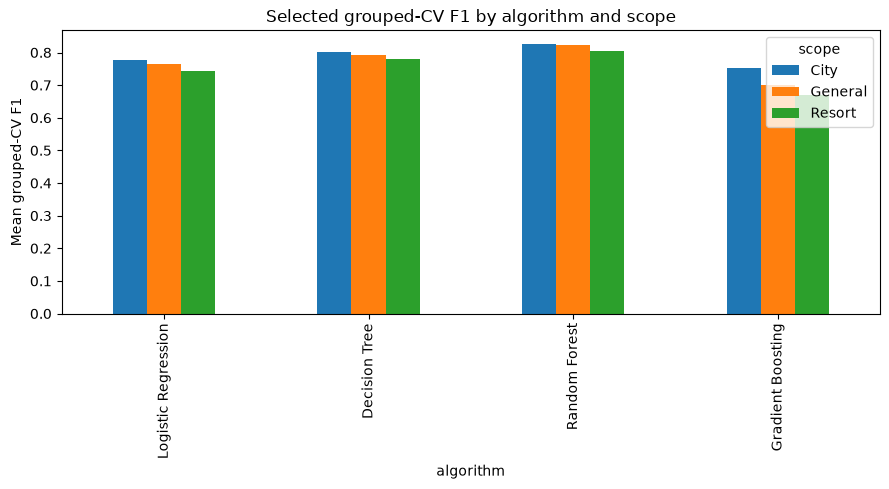

In [4]:
COMPARISON_COLUMNS = [
    'algorithm', 'scope', 'selected_stage', 'selected_mean_cv_f1',
    'selected_mean_cv_recall', 'selected_mean_cv_precision',
    'selected_mean_cv_accuracy', 'selected_mean_cv_roc_auc',
]
general_comparison = selected_cv_results.loc[
    selected_cv_results['scope'] == 'General', COMPARISON_COLUMNS
].sort_values(
    ['selected_mean_cv_f1', 'selected_mean_cv_recall', 'selected_mean_cv_roc_auc'],
    ascending=[False, False, False],
).reset_index(drop=True)
city_comparison = selected_cv_results.loc[
    selected_cv_results['scope'] == 'City', COMPARISON_COLUMNS
].sort_values('selected_mean_cv_f1', ascending=False).reset_index(drop=True)
resort_comparison = selected_cv_results.loc[
    selected_cv_results['scope'] == 'Resort', COMPARISON_COLUMNS
].sort_values('selected_mean_cv_f1', ascending=False).reset_index(drop=True)

display(Markdown('### General scope comparison'))
display(general_comparison)
display(Markdown('### City-specific scope comparison'))
display(city_comparison)
display(Markdown('### Resort-specific scope comparison'))
display(resort_comparison)

selected_cv_results.pivot(
    index='algorithm', columns='scope', values='selected_mean_cv_f1'
).loc[list(ALGORITHMS)].plot(kind='bar', figsize=(9, 5), title='Selected grouped-CV F1 by algorithm and scope')
plt.ylabel('Mean grouped-CV F1')
plt.tight_layout()
plt.show()

## 5. Same-population specialist OOF comparisons

For each algorithm, specialist performance is compared with the General model on the same hotel population. These are training-only grouped OOF differences. The OOF stage label is read from each source file and is not required to be identical across algorithms.

,algorithm,hotel_population,general_scope,specialist_scope,general_f1,specialist_f1,f1_difference,general_recall,specialist_recall,recall_difference,general_roc_auc,specialist_roc_auc,roc_auc_difference,general_precision,specialist_precision,precision_difference,general_accuracy,specialist_accuracy,accuracy_difference
0,Logistic Regression,City,General,City,0.777008,0.775924,-0.001084,0.810797,0.776632,-0.034165,0.899385,0.898737,-0.000647,0.745922,0.775216,0.029294,0.805977,0.812988,0.007011
1,Logistic Regression,Resort,General,Resort,0.724546,0.742767,0.018220,0.747770,0.852517,0.104747,0.908639,0.913472,0.004833,0.702722,0.658051,-0.044671,0.840339,0.834184,-0.006155
2,Decision Tree,City,General,City,0.802692,0.801693,-0.000999,0.855311,0.767425,-0.087886,0.913189,0.917377,0.004188,0.756172,0.839165,0.082992,0.824694,0.841714,0.017020
3,Decision Tree,Resort,General,Resort,0.765268,0.781290,0.016022,0.824650,0.899659,0.075008,0.915111,0.924447,0.009336,0.713863,0.690448,-0.023415,0.857938,0.858557,0.000619
4,Random Forest,City,General,City,0.827138,0.826652,-0.000486,0.844887,0.823429,-0.021458,0.937407,0.936938,-0.000468,0.810120,0.829901,0.019782,0.852769,0.856021,0.003252
5,Random Forest,Resort,General,Resort,0.806703,0.804564,-0.002139,0.832471,0.869920,0.037449,0.952325,0.949849,-0.002476,0.782483,0.748342,-0.034141,0.887971,0.881321,-0.006650
6,Gradient Boosting,City,General,City,0.734313,0.751916,0.017603,0.628025,0.649330,0.021306,0.905395,0.909144,0.003749,0.883909,0.892999,0.009090,0.810529,0.821363,0.010834
7,Gradient Boosting,Resort,General,Resort,0.585598,0.671033,0.085435,0.447406,0.558652,0.111246,0.916647,0.924696,0.008049,0.847309,0.840013,-0.007296,0.822183,0.846185,0.024002


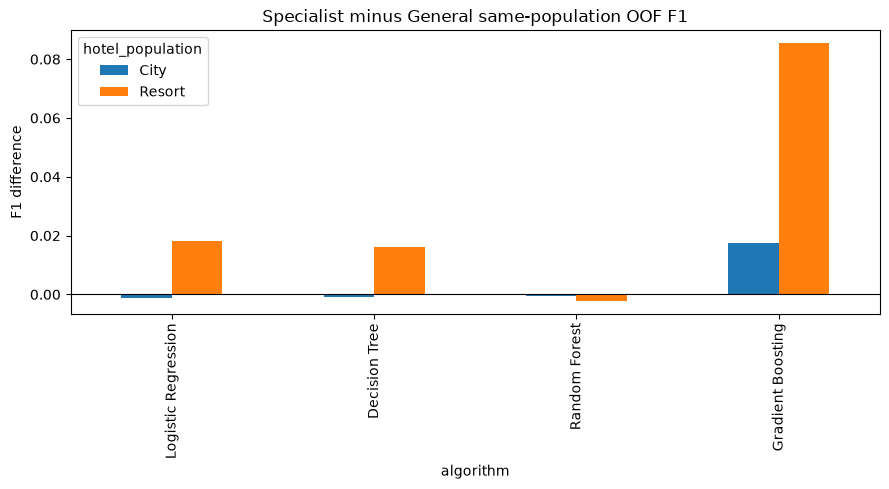

In [5]:
OOF_METRICS = ('f1', 'recall', 'roc_auc', 'precision', 'accuracy')
specialist_rows = []
for algorithm in ALGORITHMS:
    oof_frame = OOF_RESULTS[algorithm]
    for hotel_population, specialist_scope in (('City', 'City'), ('Resort', 'Resort')):
        general = oof_frame.loc[
            (oof_frame['scope'] == 'General')
            & (oof_frame['evaluation_population'] == hotel_population)
        ].iloc[0]
        specialist = oof_frame.loc[
            (oof_frame['scope'] == specialist_scope)
            & (oof_frame['evaluation_population'] == hotel_population)
        ].iloc[0]
        row = {
            'algorithm': algorithm,
            'hotel_population': hotel_population,
            'general_scope': 'General',
            'specialist_scope': specialist_scope,
        }
        for metric in OOF_METRICS:
            row[f'general_{metric}'] = general[metric]
            row[f'specialist_{metric}'] = specialist[metric]
            row[f'{metric}_difference'] = specialist[metric] - general[metric]
        specialist_rows.append(row)

specialist_oof_comparison = pd.DataFrame(specialist_rows)
assert len(specialist_oof_comparison) == 8
assert set(specialist_oof_comparison['algorithm']) == set(ALGORITHMS)
assert set(specialist_oof_comparison['hotel_population']) == {'City', 'Resort'}
display(specialist_oof_comparison)

specialist_oof_comparison.pivot(
    index='algorithm', columns='hotel_population', values='f1_difference'
).loc[list(ALGORITHMS)].plot(kind='bar', figsize=(9, 5), title='Specialist minus General same-population OOF F1')
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel('F1 difference')
plt.tight_layout()
plt.show()

# This writes the requested file only when a student executes the notebook later.
specialist_oof_comparison.to_csv(SPECIALIST_OOF_PATH, index=False)

## 6. Freeze the final algorithm and hotel-routing strategy

The final algorithm is selected only from General-scope selected grouped-CV results. Ties use Recall, then ROC-AUC. Specialist results do not change the General algorithm selection.

Routing is selected independently by hotel population using the final algorithm's same-population OOF F1. Exact F1 ties prefer General. No overall specialist F1 is calculated by averaging City and Resort F1, because F1 is nonlinear and row-level OOF predictions are not available in these result files.

In [6]:
general_candidates = general_comparison.sort_values(
    ['selected_mean_cv_f1', 'selected_mean_cv_recall', 'selected_mean_cv_roc_auc', 'algorithm'],
    ascending=[False, False, False, True],
).reset_index(drop=True)
FINAL_ALGORITHM = general_candidates.iloc[0]['algorithm']
assert FINAL_ALGORITHM in ALGORITHMS

final_algorithm_specialists = specialist_oof_comparison.loc[
    specialist_oof_comparison['algorithm'] == FINAL_ALGORITHM
].set_index('hotel_population')
city_f1_difference = final_algorithm_specialists.loc['City', 'f1_difference']
resort_f1_difference = final_algorithm_specialists.loc['Resort', 'f1_difference']
city_route_scope = 'City' if city_f1_difference > 0 else 'General'
resort_route_scope = 'Resort' if resort_f1_difference > 0 else 'General'

if city_route_scope == 'General' and resort_route_scope == 'General':
    FINAL_STRATEGY = 'General-only'
elif city_route_scope == 'City' and resort_route_scope == 'Resort':
    FINAL_STRATEGY = 'Hotel-specific'
else:
    FINAL_STRATEGY = 'Hybrid'

selected_index = selected_cv_results.set_index(['algorithm', 'scope'])
general_parameters = selected_index.loc[(FINAL_ALGORITHM, 'General'), 'selected_parameters']
city_parameters = selected_index.loc[(FINAL_ALGORITHM, city_route_scope), 'selected_parameters']
resort_parameters = selected_index.loc[(FINAL_ALGORITHM, resort_route_scope), 'selected_parameters']
general_oof = final_algorithm_specialists.loc['City']
resort_oof = final_algorithm_specialists.loc['Resort']
general_cv = selected_index.loc[(FINAL_ALGORITHM, 'General')]

frozen_final_selection = pd.DataFrame([{
    'selected_algorithm': FINAL_ALGORITHM,
    'primary_metric': 'F1',
    'general_selected_stage': general_cv['selected_stage'],
    'general_selected_cv_f1': general_cv['selected_mean_cv_f1'],
    'general_selected_cv_recall': general_cv['selected_mean_cv_recall'],
    'general_selected_cv_roc_auc': general_cv['selected_mean_cv_roc_auc'],
    'city_route_scope': city_route_scope,
    'city_general_oof_f1': general_oof['general_f1'],
    'city_specialist_oof_f1': general_oof['specialist_f1'],
    'city_f1_difference': general_oof['f1_difference'],
    'city_general_oof_recall': general_oof['general_recall'],
    'city_specialist_oof_recall': general_oof['specialist_recall'],
    'resort_route_scope': resort_route_scope,
    'resort_general_oof_f1': resort_oof['general_f1'],
    'resort_specialist_oof_f1': resort_oof['specialist_f1'],
    'resort_f1_difference': resort_oof['f1_difference'],
    'resort_general_oof_recall': resort_oof['general_recall'],
    'resort_specialist_oof_recall': resort_oof['specialist_recall'],
    'general_parameters': general_parameters,
    'city_parameters': city_parameters,
    'resort_parameters': resort_parameters,
    'final_strategy': FINAL_STRATEGY,
    'selection_basis': 'Training-only grouped CV and grouped OOF; F1 primary metric',
    'outer_test_used': False,
}])
assert len(frozen_final_selection) == 1
assert frozen_final_selection['outer_test_used'].eq(False).all()
assert city_route_scope in {'General', 'City'}
assert resort_route_scope in {'General', 'Resort'}
display(general_candidates)
display(frozen_final_selection)

# This writes the requested file only when a student executes the notebook later.
frozen_final_selection.to_csv(FROZEN_SELECTION_PATH, index=False)

,algorithm,scope,selected_stage,selected_mean_cv_f1,selected_mean_cv_recall,selected_mean_cv_precision,selected_mean_cv_accuracy,selected_mean_cv_roc_auc
0,Random Forest,General,tuned,0.821846,0.841707,0.802962,0.864703,0.943806
1,Decision Tree,General,tuned,0.793004,0.847457,0.745131,0.835971,0.916018
2,Logistic Regression,General,tuned,0.763610,0.794627,0.735081,0.817626,0.904447
3,Gradient Boosting,General,baseline,0.699085,0.581630,0.877172,0.814480,0.910866


,selected_algorithm,primary_metric,general_selected_stage,general_selected_cv_f1,general_selected_cv_recall,general_selected_cv_roc_auc,city_route_scope,city_general_oof_f1,city_specialist_oof_f1,city_f1_difference,...,resort_specialist_oof_f1,resort_f1_difference,resort_general_oof_recall,resort_specialist_oof_recall,general_parameters,city_parameters,resort_parameters,final_strategy,selection_basis,outer_test_used
0,Random Forest,F1,tuned,0.821846,0.841707,0.943806,General,0.827138,0.826652,-0.000486,...,0.804564,-0.002139,0.832471,0.86992,"{""bootstrap"": true, ""class_weight"": ""balanced""...","{""bootstrap"": true, ""class_weight"": ""balanced""...","{""bootstrap"": true, ""class_weight"": ""balanced""...",General-only,Training-only grouped CV and grouped OOF; F1 p...,False
